## Elinora Pentcheva
## Lab #2
# Comparing JPSP abstracts from 1965 to today

Lab #2 Assignment ~ Conduct Text Analysis

**#1-  Collect some texts.  Compare them in a number of ways.  You will likely want to have them be “bags of words.”**

I have chosen to analyze how content published by the Journal of Personality and Social Psychology has evolved from the journal's inception in 1965 to today. To this end, I have collected abstracts from the American Psychology Association (APA) website. I have collected 40 abstracts from issues published in the first five years of the journal's existence (1965-1970) and 40 abstracts from the last five years (2021-2026).
Source: https://psycnet.apa.org/search
See raw data files in data folder.

**#2-  Prepare the text through removing upper case, white space, punctuation, and consider stemming the words, if appropriate for your purpose.**

In [9]:
!pip install textstat wordcloud textblob snowballstemmer scikit-learn


import re
import string
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from scipy.stats import chi2_contingency
from textblob import TextBlob
from itertools import islice
from wordcloud import WordCloud
from textstat import flesch_reading_ease, flesch_kincaid_grade
import snowballstemmer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# Load texts from files
with open("../data/jpsp_65-70.txt", "r", encoding="latin-1") as f:
    text_a = f.read()

with open("../data/jpsp_21-26.txt", "r", encoding="latin-1") as f:
    text_b = f.read()

stemmer = snowballstemmer.stemmer('english')

# Remove PsycInfo boilerplate
boilerplate = r'\(PsycInfo Database Record \(c\) \d{4} APA, all rights reserved\)'
text_a = re.sub(boilerplate, '', text_a)
text_b = re.sub(boilerplate, '', text_b)

# Using a custom minimal stopword list
def preprocess(text, stopword_list):
    text = text.lower()
    text = re.sub(f"[{string.punctuation}]", "", text)  # Remove punctuation
    words = text.split()

    # Apply stemming and remove stopwords
    words = [stemmer.stemWord(word) for word in words if word not in stopword_list]

    return words

# Use a custom stopword list
custom_stopwords = {
    "ref", "the", "a", "an", "and", "or", "but", "if", "because", "as", "until", "while",
    "of", "at", "by", "for", "with", "about", "against", "between", "into", "through",
    "during", "before", "after", "above", "below", "to", "from", "up", "down",
    "in", "out", "on", "off", "over", "under", "again", "further", "then", "once"
}

# Example of switching stopword sets
tokens_a = preprocess(text_a, custom_stopwords)  # Use the minimal list
tokens_b = preprocess(text_b, custom_stopwords)  # Use the minimal list






[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip



**#3-  Generate relative word frequencies for each bag of words, and compare them to each other.  Articulate what differences (if any) you notice and whether this comports with a theory of why these bags of words should be similar or different.**

In [10]:
# Compute Word Frequencies
freq_a = Counter(tokens_a)
freq_b = Counter(tokens_b)

# Normalize frequencies (avoid division by zero)
total_a = sum(freq_a.values()) + 1e-10
total_b = sum(freq_b.values()) + 1e-10

rel_freq_a = {word: count / total_a for word, count in freq_a.items()}
rel_freq_b = {word: count / total_b for word, count in freq_b.items()}

from collections import Counter

# Function to get top N most indicative words based on relative frequency ratios
def top_indicative_terms(freq_a, freq_b, n=10):
    """ Finds the top N terms that are most overrepresented in text_a vs text_b. """
    indicative_scores = {term: freq_a.get(term, 0) / (freq_b.get(term, 0) + 1e-10) for term in freq_a}
    top_terms = sorted(indicative_scores.items(), key=lambda x: x[1], reverse=True)[:n]
    return top_terms

# Compute most indicative words
top_words_a = top_indicative_terms(rel_freq_a, rel_freq_b, n=10)
top_words_b = top_indicative_terms(rel_freq_b, rel_freq_a, n=10)

# Print Results
print("\n===== TOP 10 MOST INDICATIVE WORDS =====\n")
print("Top 10 most indicative words in text_a:")
for word, score in top_words_a:
    print(f"{word}: {score:.5f}")

print("\nTop 10 most indicative words in text_b:")
for word, score in top_words_b:
    print(f"{word}: {score:.5f}")


===== TOP 10 MOST INDICATIVE WORDS =====

Top 10 most indicative words in text_a:
ss: 188519977.49015
choic: 59088351.15363
disson: 47833427.12437
reward: 36578503.09510
communic: 33764772.08779
his: 28137310.07316
delay: 28137310.07316
children: 25323579.06584
concept: 25323579.06584
reinforc: 22509848.05852

Top 10 most indicative words in text_b:
we: 150343015.61816
trust: 48168150.63494
wellb: 45248868.77828
life: 39410305.06495
how: 32112100.42330
our: 30652459.49496
black: 27733177.63830
first: 26273536.70997
understand: 24813895.78164
american: 23354254.85331


The top indicative words in each text offer an interesting window into the style of writing in the field of psychology through time. In text a (1965-1970), the top word is "ss" which stands for "subjects" - a form of shorthand we no longer use to refer to participants. Words like "choice", "dissonance", "reward", "reinforcement" are indicative of the prevailing major theories at the time: conditioning theories & dissonance theories. I've chosen to leave the word "his" in the list instead of dismissing it as a stopword, because it also reflects the norms of the time - accepting male pronouns as default for all participants, or sometimes only including male participants in the sample.

The top words in text b (2021-2026) point to several shifts that have happened in the sixty years since the creation of this publication. Words like "trust", "life", and "wellbeing" point to topics that are of great concern in modern social sciences. "How" and "understand" may indicate a more reflective scientific philosophy, focused on understanding processes and mechanisms, and elucidating the how behind the phenomenon. The presence of the word "Black" in the list points to the increase in DEI research, and increased attention being paid to the experience of non-white individuals, underrepresented minorities, and other marginalized groups. The word "American" is also an interesting addition because large scale cross-cultural comparisons in social psychology are relatively new as well. While research in the 60s treated WEIRD samples as an unspoken standard, recent research in the field has started highlighting specifically when findings are thought to apply to American samples only, vs when they are thought to generalize, or have been tested empirically against samples of different cultural backgrounds. I will dive into this further in the bigram analysis below.

**#4-  Run statistical tests of association between the bags of words (correlation, cosine similarity, regression or Chi-squared), and explain what they indicate.**

In [11]:
# Convert text to vectors for similarity calculation
vectorizer = CountVectorizer()
X = vectorizer.fit_transform([" ".join(tokens_a), " ".join(tokens_b)])
cos_sim = cosine_similarity(X, X)[0, 1]

# Pearson Correlation
df = pd.DataFrame.from_dict([rel_freq_a, rel_freq_b]).fillna(0).T
df.columns = ["text_a", "text_b"]
corr = df.corr().iloc[0, 1]

# Chi-Squared Test
words = list(set(freq_a.keys()).union(set(freq_b.keys())))
contingency_table = [[freq_a.get(word, 0), freq_b.get(word, 0)] for word in words]
chi2, p, _, _ = chi2_contingency(contingency_table)

# Print Results
print("\n===== TEXT COMPARISON RESULTS =====\n")
print("Cosine Similarity:", cos_sim)
print("Pearson Correlation:", corr)
print(f"Chi-Squared Test: Statistic={chi2:.5f}, p-value={p:.5f}")



===== TEXT COMPARISON RESULTS =====

Cosine Similarity: 0.556614532409541
Pearson Correlation: 0.4767065407912339
Chi-Squared Test: Statistic=4852.69051, p-value=0.00000


The statistical measures show some interesting parallels between the two corpora. The cosine similarity of .557 indicates moderate similarity, which makes sense as the texts share a meaningful common vocabulary (being from the same discipline and the same journal) but they're far from being identical. The Pearson correlation of .477 confirms that the texts share a core vocabulary, but there's meaningful divergence in the shape of the distributions of word frequency, which supports my earlier intuition that the style and emphasis have shifted throughout the years. It is interesting to highlight the very large chi-squared statistic with a highly significant p-value, which means that the two corpora are linguistically distinct in a way that is statistically measurable.

**#5a-  Do one more big thing-- either a sentiment analysis of the bags of wordsFor whichever thing you choose, explain what you are doing and whatever you find makes sense in some way theoretically.**


In [13]:
from nltk.sentiment import SentimentIntensityAnalyzer
import nltk

nltk.download('vader_lexicon')
sia = SentimentIntensityAnalyzer()

print("\nVADER Sentiment Analysis - Text A:")
print(sia.polarity_scores(text_a))

print("\nVADER Sentiment Analysis - Text B:")
print(sia.polarity_scores(text_b))


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/esp2171/nltk_data...



VADER Sentiment Analysis - Text A:
{'neg': 0.075, 'neu': 0.771, 'pos': 0.154, 'compound': 0.9999}

VADER Sentiment Analysis - Text B:
{'neg': 0.057, 'neu': 0.807, 'pos': 0.136, 'compound': 1.0}


Both corpora are overwhelmingly neutral, which is exactly what I would expect from a collection of academic abstracts. The neu scores of .771 and .807 reflect the objectivity/neutrality we would aim for in scientific writing, which is a good sanity check for the content of our analysis.

There are some subtle differences between the two texts, in that text a ('65-'70) scores higher both on the positive and the negative measures, whereas text b ('21-'26) scores higher on the neutral measure, signalling that social psychologists in the latter part of the 60s may have used slightly more valenced language than we do today, but since the differences are small here and VADER is not trained on academic writing, it's important to not over-interpret.

**#5b-- Do one more big thing-- rerun your analysis but using bigrams and/or trigrams; For whichever thing you choose, explain what you are doing and whatever you find makes sense in some way theoretically.**

In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer

text_a_clean = " ".join(tokens_a)
text_b_clean = " ".join(tokens_b)

# Initialize TF-IDF Vectorizer for bigrams
vectorizer_bigram = TfidfVectorizer(ngram_range=(2, 2))  # This extracts bigrams

# Compute TF-IDF scores for bigrams
X_tfidf_bigram = vectorizer_bigram.fit_transform([text_a_clean, text_b_clean])

# Get feature names (bigrams)
feature_names_bigram = vectorizer_bigram.get_feature_names_out()

# Convert TF-IDF scores to a DataFrame
df_tfidf_bigram = pd.DataFrame(X_tfidf_bigram.toarray(), columns=feature_names_bigram, index=["text_a", "text_b"])

# Get top 10 TF-IDF bigrams for each text
top_bigrams_a_tfidf = df_tfidf_bigram.loc["text_a"].sort_values(ascending=False).head(10)
top_bigrams_b_tfidf = df_tfidf_bigram.loc["text_b"].sort_values(ascending=False).head(10)

# Print results for bigrams
print("\n===== TOP 10 MOST INDICATIVE BIGRAMS (TF-IDF Bigrams) =====\n")
print("Top 10 most important bigrams in text_a (JPSP 65-70) using TF-IDF:")
print(top_bigrams_a_tfidf)

print("\nTop 10 most important bigrams in text_b (JPSP 21-26) using TF-IDF:")
print(top_bigrams_b_tfidf)


===== TOP 10 MOST INDICATIVE BIGRAMS (TF-IDF Bigrams) =====

Top 10 most important bigrams in text_a (JPSP 65-70) using TF-IDF:
ss were           0.131896
it was            0.131896
who had           0.117241
was found         0.117241
ss who            0.117241
group were        0.102586
attitud chang     0.093845
disson theori     0.087930
colleg student    0.073275
did not           0.062563
Name: text_a, dtype: float64

Top 10 most important bigrams in text_b (JPSP 21-26) using TF-IDF:
show that           0.141252
life satisfact      0.099263
suggest that        0.091814
sensori consumpt    0.079410
we show             0.079410
structur racism     0.079410
outward appear      0.079410
cognit function     0.079410
we find             0.079410
our find            0.079410
Name: text_b, dtype: float64


The bigram analysis allows us to add some nuance and depth to the differences found by contrasting unigrams. The top bigrams in text a (1965-1970) reflect the linguistic norms at the time: "ss were", "ss who", "group were" reflect the old language used to describe participants. Expressions like "was found", "it was" reflect the heavy passive voice, which has since evolved into more active sentence construction (more on that below). "Attitud[e] chang[e]" and "disson[ance] theori[es]" highlight the theory-driven framing of the time. The presence of "colleg[e] student" is especially interesting as it reflects the classic sample that dominated that era of research. The fact that the bigram "did not" makes this list is also interesting, as it may suggest that papers often framed their findings as contrasts to an expected outcome.

The top bigrams in text b (2021-2026) reflect a few ways in which the field has evolved. Expressions like "show that", "we find", "we show", "our find[ings]", reflect the active voice that modern APA guidelines encourage, as opposed to the passive voice of the 60s. Using the phrase "suggest that" might be indicative of more hedged or cautious claims, consistent with a field in the midst of grappling with the replication crisis. "Structur[al] racism", "cognit[ive] function", "life satisfact[ion]", echo the broadening of topics our field is concerned with. "Sensor[y] consumpt[ion]" and "outward appear[ance]" might reflect the increase in specialized operationalizations and narrowing of constructs.


In [19]:
from scipy.stats import pearsonr

# ==== ADDING STATISTICAL COMPARISONS BASED ON BIGRAM DISTRIBUTIONS ====

# 1. Cosine similarity between the two bigram TF-IDF vectors
cosine_sim_bigram = cosine_similarity(X_tfidf_bigram[0:1], X_tfidf_bigram[1:2])[0][0]
print(f"\nCosine similarity (bigrams): {cosine_sim_bigram:.5f}")

# 2. Pearson correlation between bigram distributions
# Flatten both vectors
a_bigram_values = df_tfidf_bigram.loc["text_a"].values
b_bigram_values = df_tfidf_bigram.loc["text_b"].values
pearson_corr_bigram, p_corr = pearsonr(a_bigram_values, b_bigram_values)
print(f"Pearson correlation (bigrams): {pearson_corr_bigram:.5f}, p-value: {p_corr:.5f}")

# 3. Chi-square test based on raw frequency counts instead of TF-IDF
# We need raw bigram frequency counts for this test:
from sklearn.feature_extraction.text import CountVectorizer

# Create bigram frequency count matrix
count_vectorizer_bigram = CountVectorizer(ngram_range=(2, 2))
X_bigram_counts = count_vectorizer_bigram.fit_transform([text_a_clean, text_b_clean])
bigram_counts = pd.DataFrame(X_bigram_counts.toarray(), columns=count_vectorizer_bigram.get_feature_names_out(), index=["text_a", "text_b"])

# Build contingency table for Chi-square test
contingency_table = bigram_counts.T.values  # shape = (bigrams, 2)

# Chi-square test
chi2_stat, chi2_p, _, _ = chi2_contingency(contingency_table)
print(f"Chi-square test (bigrams): Chi² = {chi2_stat:.5f}, p-value = {chi2_p:.5f}")


Cosine similarity (bigrams): 0.03653
Pearson correlation (bigrams): -0.58025, p-value: 0.00000
Chi-square test (bigrams): Chi² = 9835.55538, p-value = 0.00000


The statistical measures are even more striking for the bigram comparison than for the unigrams above. The cosine similarity is nearly 0 (.037), meaning that the two corpora share almost no bigrams, and flagging a massive drop from our unigram cosine similarity of .557. This would suggest that while the texts share individual words (common psychology vocabulary), the way those words are combined is vastly different across eras. This further supports the notion of significant stylistic change across time.

The negative pearson correlation suggests that bigrams that are commonly used in one era are absent in the other, and vice versa. For example, the passive sentence constructions of the '65-'70 era ("it was found", "ss were") have likely been replaced entirely by the more active constructions encouraged by modern guidelines ("we show", "we find", etc.)

The chi-square value has more than doubled from the unigram test, confirming that bigram distributions are even more different statistically than individual word distributions, i.e. the difference in patterns of language is even more pronounced than the difference in vocabulary.

Taken together, these findings suggest that while the corpora may be moderately similar at the single word level (cosine similarity of .557), they are essentially entirely different at the bigram level (.037). So while the lexical content of psychology papers may have remained somewhat consistent over the last sixty years, the grammatical structure and rhetorical style has transformed massively.

**#5c-- Do one more big thing-- either a readability analysis.  For whichever thing you choose, explain what you are doing and whatever you find makes sense in some way theoretically.**

In [15]:

# Readability Scores
readability_a = flesch_reading_ease(text_a)
readability_b = flesch_reading_ease(text_b)
fk_grade_a = flesch_kincaid_grade(text_a)
fk_grade_b = flesch_kincaid_grade(text_b)



print("\nReadability Scores:")
print(f"Text A - Flesch Reading Ease: {readability_a:.2f}, Flesch-Kincaid Grade: {fk_grade_a:.2f}")
print(f"Text B - Flesch Reading Ease: {readability_b:.2f}, Flesch-Kincaid Grade: {fk_grade_b:.2f}")






Readability Scores:
Text A - Flesch Reading Ease: 25.49, Flesch-Kincaid Grade: 15.05
Text B - Flesch Reading Ease: 13.95, Flesch-Kincaid Grade: 16.51


Finally, it's interesting to compare the readability scores of the two texts. The abstracts from text a (1965-1970) score nearly twice as high on ease of readability than those from text b (2021-2026). While both are in the "very difficult" range, modern JPSP abstracts seem to be significantly more complex by this metric (25.49 vs 13.95). Modern abstracts also score higher on the grade level (16.51) than old abstracts (15.05), indicating that a reader is required to have slightly more education to make sense of them. This is intuitively consistent with a few trends in the literature: (1) Modern papers use more statistical and methodology-related jargon, and precise technical language, as the methods of our field have become more rigorous and standards have risen. (2) The replication crisis has pushed us towards more careful and precise claims and away from broad generalizations, which adds syntactic complexity to the writing. (3) As constructs have proliferated in the field, the APA has required increasingly more qualified and specific operationalizations of each one.

**Extra credit: do some wordclouds of your texts**



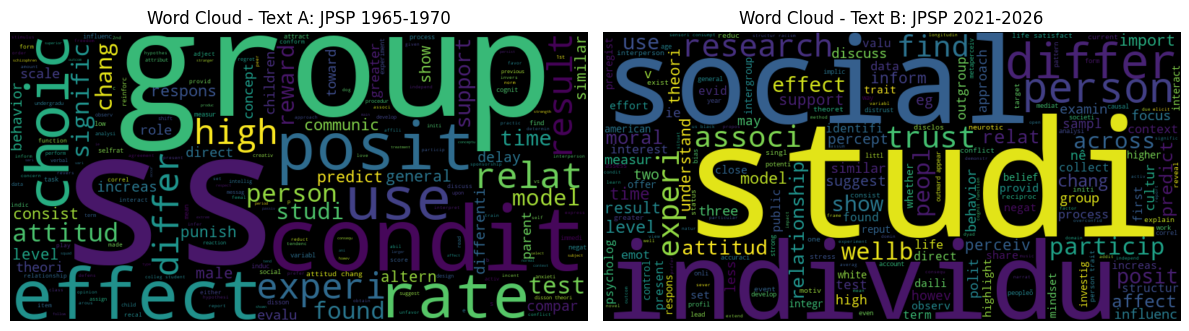

In [17]:
# Word Cloud Visualization
wc_a = WordCloud(width=800, height=400).generate(" ".join(tokens_a))
wc_b = WordCloud(width=800, height=400).generate(" ".join(tokens_b))

# Display Word Clouds Side-by-Side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(wc_a, interpolation="bilinear")
axes[0].axis("off")
axes[0].set_title("Word Cloud - Text A: JPSP 1965-1970")

axes[1].imshow(wc_b, interpolation="bilinear")
axes[1].axis("off")
axes[1].set_title("Word Cloud - Text B: JPSP 2021-2026")

plt.tight_layout()
plt.show()